# Regime-Switching GEMINI — Demo

This notebook demonstrates replacing PGscen's static covariance structure with a
multi-regime model (GMM on gaussianized deviations).

**Pipeline:**
1. Load ERCOT load data (same format as `pgscen-load`)
2. Create a `RegimeSwitchingGeminiEngine`
3. Call `fit_regimes()` → BIC automatically selects the number of regimes K
4. Generate scenarios → the correct regime is detected automatically
5. Compare with the standard PGscen engine

### Global parameters

All notebook constants are defined here for easy experimentation:
- **`date`**: target day for which scenarios will be generated
- **`load_zone`**: ERCOT load zone to visualize (`Coast`, `East`, `Far_West`, …)
- **`MAX_REGIMES`**: upper bound on the number of regimes tested by BIC search
- **`PCA_COMPONENTS`**: dimensionality of the GMM embedding space
- **`NEAREST_DAYS`**: seasonal window — only historical days within ±50 days of the target date are used for training
- **`NSCEN`**: number of Monte Carlo scenarios to generate
- **`ASSET_RHO` / `HORIZON_RHO`**: graphical lasso regularization for the spatial and temporal covariance matrices

In [60]:
# ── Configuration ──────────────────────────────────────────────────────────
date      = "2018-06-15"
out_dir   = "/Users/val/Desktop/Princeton"
load_zone = "Coast"

MAX_REGIMES    = 5
PCA_COMPONENTS = 5
NEAREST_DAYS   = 500    # utilisé uniquement pour le fit standard et create_scenario
NSCEN          = 1000
ASSET_RHO      = 0.05
HORIZON_RHO    = 0.05

### Imports and environment setup

`R_HOME` must be set **before** any `pgscen` import because the package uses `rpy2`
to call R routines (GPD gaussianization, graphical lasso). Without this variable,
`rpy2` picks up a system R version that is incompatible with the conda environment.

`sys.path.insert(0, out_dir)` makes Python find `regime_switching.py` in the
project directory without installing it as a package.

In [61]:
import sys, os

# R_HOME must be set before any rpy2/pgscen import
os.environ['R_HOME'] = '/Users/val/miniconda3/envs/pgscen/lib/R'

sys.path.insert(0, out_dir)          # to find regime_switching.py
os.chdir(out_dir)

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from datetime import datetime
from regime_switching import RegimeSwitchingGeminiEngine

# standard PGscen imports
from pgscen.utils.data_utils import (
    split_actuals_hist_future, split_forecasts_hist_future
)
from pgscen.engine import GeminiEngine

print("Imports OK")

Imports OK


## 1. Load data

The ERCOT dataset covers **2017–2018** and contains hourly actuals (`load_actual`)
and day-ahead forecasts (`load_forecast`) for 8 load zones.

All timestamps are in **UTC**: an ERCOT "day D" starts at **06:00 UTC**
(= midnight CST/CDT local time). The data is split into two subsets:
- **hist**: all days *before* the target day → used to train the model
- **future**: the target day itself → used to generate scenarios

In [62]:
from pathlib import Path

# ERCOT day starts at 06:00 UTC (= midnight local CST/CDT)
scen_start_time = pd.to_datetime(f'{date} 06:00:00', utc=True)
scen_timesteps  = pd.date_range(start=scen_start_time, periods=24, freq='H')

# load data directly from project CSVs
_data_path = Path(out_dir) / "PGscen-new" / "data"
load_actual_df = pd.read_csv(
    _data_path / 'ERCOT/Load/Actual/load_actual_1h_zone_2017_2018_utc.csv',
    parse_dates=['Time'], index_col='Time'
)
load_forecast_df = pd.read_csv(
    _data_path / 'ERCOT/Load/Day-ahead/load_day_ahead_forecast_zone_2017_2018_utc.csv',
    parse_dates=['Issue_time', 'Forecast_time']
)

# hist / future split
load_actual_hist, load_actual_future = split_actuals_hist_future(
    load_actual_df, scen_timesteps, in_sample=False
)
load_forecast_hist, load_forecast_future = split_forecasts_hist_future(
    load_forecast_df, scen_timesteps, in_sample=False
)

print(f"History : {load_actual_hist.index.min().date()} -> "
      f"{load_actual_hist.index.max().date()}")
print(f"Zones   : {list(load_actual_hist.columns)}")

History : 2017-01-01 -> 2018-06-15
Zones   : ['Coast', 'East', 'Far_West', 'North', 'North_Central', 'South', 'South_Central', 'West']


## 2. Fit the regime-switching model

`fit_regimes()` automatically runs the following steps:

1. **Gaussianization** — forecast deviations are mapped to N(0,1) via a GPD + ECDF
   transform (same pipeline as standard GEMINI)
2. **PCA** — the gaussianized matrix (days × features) is reduced to `PCA_COMPONENTS`
   dimensions to avoid the curse of dimensionality during clustering
3. **BIC-based regime selection** — GMMs are fitted for k = 1 … `MAX_REGIMES`;
   the k that minimizes BIC is selected
4. **Regime labeling** — each historical day is assigned a regime label k = 0 … K-1
5. **Per-regime GeminiModel** — for each regime k, a graphical lasso is fitted on the
   days labeled k, yielding regime-specific matrices Σ_spatial ⊗ Σ_temporal

In [63]:
rs_engine = RegimeSwitchingGeminiEngine(
    load_actual_hist,
    load_forecast_hist,
    scen_start_time,
    asset_type='load'
)

rs_engine.fit_regimes(
    max_regimes    = MAX_REGIMES,
    pca_components = PCA_COMPONENTS,
    asset_rho      = ASSET_RHO,
    horizon_rho    = HORIZON_RHO,
    # nearest_days supprimé → utilise tout l'historique pour apprendre les régimes
)

rs_engine.regime_summary()

[RegimeSwitching] Gaussianizing historical deviations...
  → 529 historical days × 192 features
  → PCA: 5 components explain 49.4% of variance
[RegimeSwitching] Selecting number of regimes (BIC, k=1..5)...
  k=1  BIC=15170.7
  k=2  BIC=15214.4
  k=3  BIC=15285.4
  k=4  BIC=15362.3
  k=5  BIC=15471.8
  → Best k = 1 (lowest BIC = 15170.7)
[RegimeSwitching] Fitting per-regime GEMINI models...
  Regime 0: 529 days  ✓
[RegimeSwitching] fit_regimes() complete.


  Regime-Switching Summary  (1 regimes)

  Regime 0  —  529 days (100%)
    Top weekdays : Monday(76), Tuesday(76), Wednesday(76)
    Top months   : March(62), May(62), January(61)
    Asset cov  (diag mean) : 1.7304
    Horizon cov (diag mean): 0.5769




## 3. Regime visualization in PCA space

Each dot is a historical training day projected onto the first two principal
components and colored by its GMM regime label. Well-separated clusters confirm
that the regimes capture distinct weather or demand patterns.

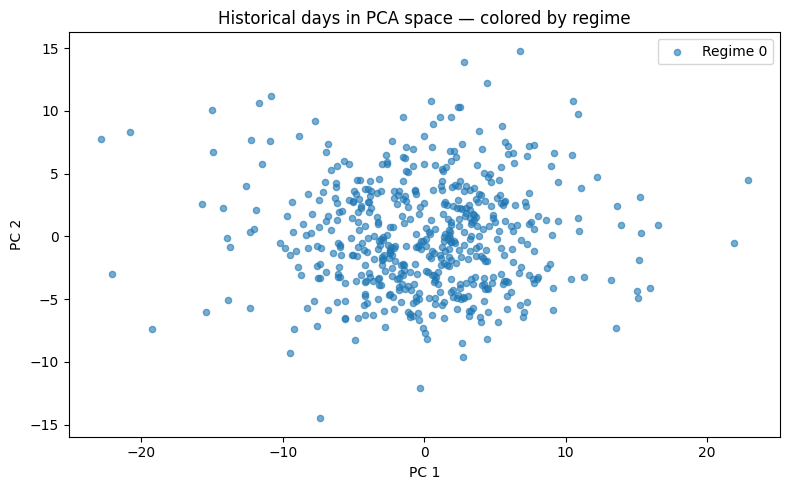

In [64]:
from pgscen.model import GeminiModel
from pgscen.utils.r_utils import gaussianize, standardize

# retrieve PCA embedding of all historical days
labels = rs_engine.regime_labels
X_full = rs_engine._base_model.gauss_df.values
X_pca  = rs_engine.pca_embed.transform(X_full)

K = rs_engine.n_regimes
colors = plt.cm.tab10(np.linspace(0, 0.9, K))

fig, ax = plt.subplots(figsize=(8, 5))
for k in range(K):
    mask = labels.values == k
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[colors[k]], alpha=0.6, s=20, label=f'Regime {k}')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_title('Historical days in PCA space — colored by regime')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Seasonal profile of regimes

Distribution of each regime's days by **month** and **day of week**. If regimes
capture seasonal structure (summer vs. winter) or weekly patterns (weekday vs.
weekend), it will appear as a concentration on specific bars.

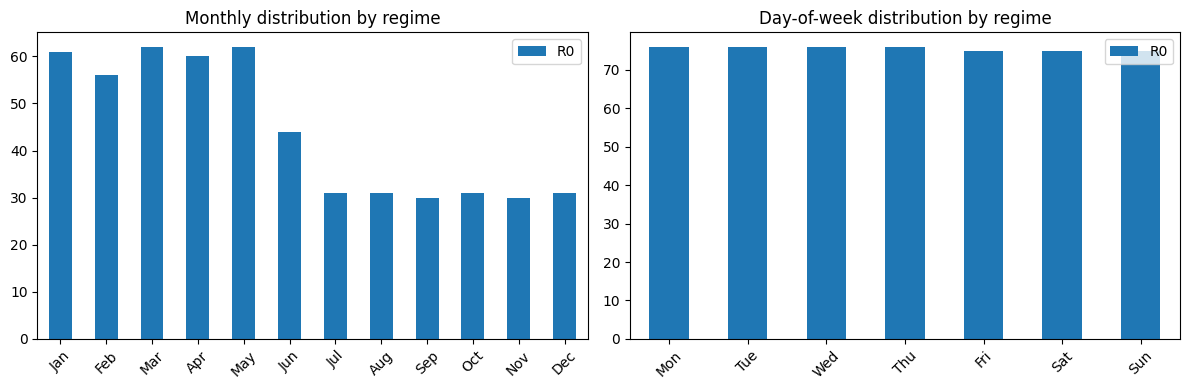

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
dow_labels   = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

# monthly distribution — reindex to all 12 months to avoid length mismatch
# when the seasonal window does not cover every month
month_data = pd.DataFrame({
    f'R{k}': labels[labels == k].index.month.value_counts()
    for k in range(K)
}).reindex(range(1, 13), fill_value=0)
month_data.index = month_labels
month_data.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Monthly distribution by regime')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# day-of-week distribution
dow_data = pd.DataFrame({
    f'R{k}': labels[labels == k].index.dayofweek.value_counts()
    for k in range(K)
}).reindex(range(7), fill_value=0)
dow_data.index = dow_labels
dow_data.plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title('Day-of-week distribution by regime')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Generate scenarios with the regime-switching model

`create_scenario()` automatically detects the regime of the target day by
projecting its historical deviations into PCA space and querying the GMM, then
uses the regime-specific covariance matrices Σ_spatial ⊗ Σ_temporal to draw
`NSCEN` Monte Carlo trajectories. Results are stored in
`rs_engine.scenarios['load']`.

In [66]:
rs_engine.create_scenario(NSCEN, load_forecast_future)
rs_scens = rs_engine.scenarios['load'][load_zone].astype(float)
print(f"Scenarios generated : {rs_scens.shape}  "
      f"(active regime: {rs_engine.active_regime})")

/Users/val/Desktop/Princeton/regime_switching.py:285: UserWarning: Date 2018-06-15 not in training history; using nearest day 2018-06-14 (regime 0).
  warnings.warn(


[RegimeSwitching] Using regime 0 (529 training days)
Scenarios generated : (1000, 24)  (active regime: 0)


## 6. Standard PGscen scenarios (baseline)

Same pipeline as the original GEMINI: a single `GeminiModel` trained on all
historical days in the seasonal window, with no regime distinction. This serves
as the baseline for evaluating the contribution of regime-switching.

In [67]:
std_engine = GeminiEngine(
    load_actual_hist, load_forecast_hist,
    scen_start_time, asset_type='load'
)
std_engine.fit(ASSET_RHO, HORIZON_RHO, nearest_days=NEAREST_DAYS)
std_engine.create_scenario(NSCEN, load_forecast_future)
std_scens = std_engine.scenarios['load'][load_zone].astype(float)
print(f"Standard scenarios : {std_scens.shape}")

Standard scenarios : (1000, 24)


## 7. Visual comparison of scenarios

Fan chart of all `NSCEN` trajectories for zone `load_zone`. The red line is the
empirical mean; the shaded band covers the 10%–90% interval. A well-calibrated
regime-switching model should produce a tighter or better-centered band when the
active regime is homogeneous.

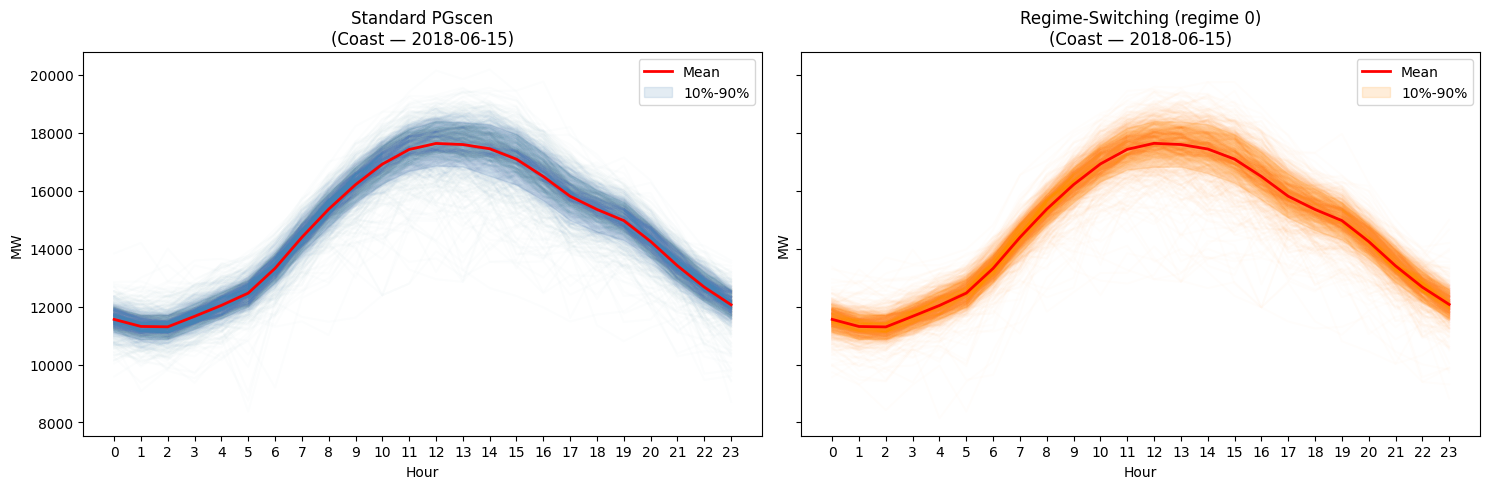

In [68]:
hours = range(24)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, scens, title, color in zip(
    axes,
    [std_scens, rs_scens],
    [f'Standard PGscen\n({load_zone} — {date})',
     f'Regime-Switching (regime {rs_engine.active_regime})\n({load_zone} — {date})'],
    ['steelblue', 'darkorange']
):
    for i in range(len(scens)):
        ax.plot(hours, scens.iloc[i].values, color=color, alpha=0.015)
    ax.plot(hours, scens.mean().values, color='red', lw=2, label='Mean')
    ax.fill_between(
        hours,
        scens.quantile(0.10).values,
        scens.quantile(0.90).values,
        alpha=0.15, color=color, label='10%-90%'
    )
    ax.set_title(title)
    ax.set_xlabel('Hour')
    ax.set_ylabel('MW')
    ax.set_xticks(hours)
    ax.legend()

plt.tight_layout()
plt.show()

## 8. Covariance structure comparison

Four heatmaps comparing the standard model and the active regime side by side:
- **Spatial covariance** Σ_spatial (zones × zones): correlations among the 8 ERCOT load zones
- **Temporal covariance** Σ_temporal (hours × hours): correlations among the 24 hourly time steps

GEMINI models the joint covariance as a Kronecker product Σ = Σ_spatial ⊗ Σ_temporal.
If the active regime differs noticeably from the global model, it confirms that
regime-switching captures a non-trivial conditional structure.

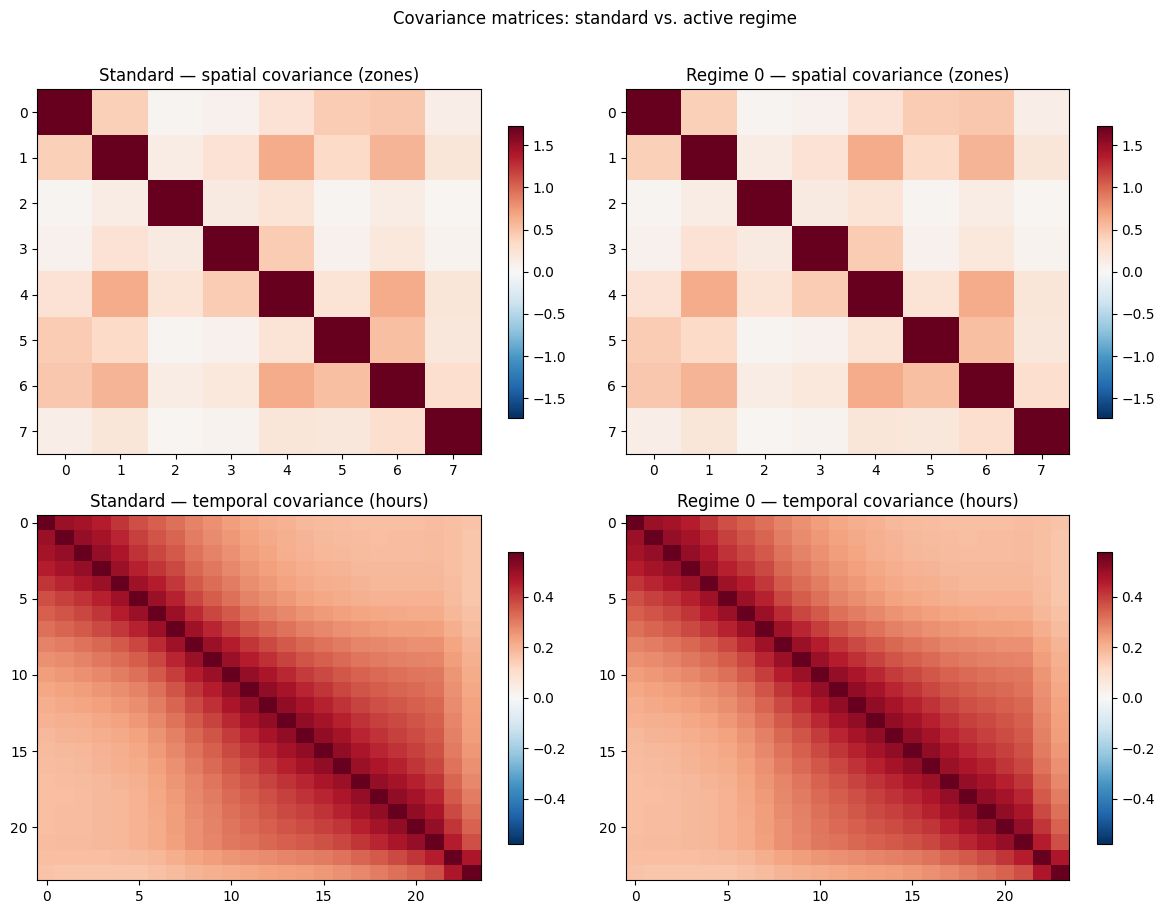

In [69]:
k_active  = rs_engine.active_regime
rs_model  = rs_engine.regime_models[k_active]
std_model = std_engine.model

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

def plot_cov(ax, mat, title):
    im = ax.imshow(mat, cmap='RdBu_r', aspect='auto',
                   vmin=-np.abs(mat).max(), vmax=np.abs(mat).max())
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8)

plot_cov(axes[0,0], std_model.asset_cov.values,   'Standard — spatial covariance (zones)')
plot_cov(axes[0,1], rs_model.asset_cov.values,    f'Regime {k_active} — spatial covariance (zones)')
plot_cov(axes[1,0], std_model.horizon_cov.values, 'Standard — temporal covariance (hours)')
plot_cov(axes[1,1], rs_model.horizon_cov.values,  f'Regime {k_active} — temporal covariance (hours)')

plt.suptitle('Covariance matrices: standard vs. active regime', y=1.01)
plt.tight_layout()
plt.show()

## 9. Hourly dispersion comparison

Empirical standard deviation of the scenarios for each hour of the day. Lower
dispersion in the regime-switching model means that conditioning on the day's
regime reduces uncertainty — the expected outcome when regimes correspond to
homogeneous demand or weather conditions.

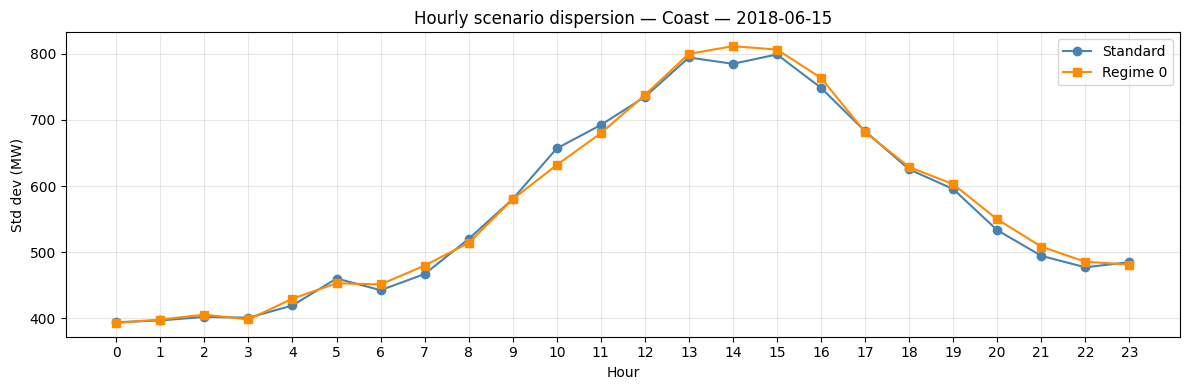

In [70]:
fig, ax = plt.subplots(figsize=(12, 4))

std_std = std_scens.std()
rs_std  = rs_scens.std()

ax.plot(hours, std_std.values, 'o-', color='steelblue', label='Standard')
ax.plot(hours, rs_std.values,  's-', color='darkorange',
        label=f'Regime {k_active}')
ax.set_xlabel('Hour')
ax.set_ylabel('Std dev (MW)')
ax.set_title(f'Hourly scenario dispersion — {load_zone} — {date}')
ax.set_xticks(hours)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()